C:\Users\Nilavra Ghosh\AppData\Local\Temp\ipykernel_14176\4119924813.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, skiprows=header_idx, delim_whitespace=True)



--- Performance Parameters for EE334 ---
 alpha        CL     CL/CD  CL^1.5/CD        CM
  -4.0 -0.072157 -2.063338        NaN -0.031565
  -3.5 -0.039718 -1.313860        NaN -0.039205
  -3.0 -0.007263 -0.283944        NaN -0.046842
  -2.5  0.025202  1.093979   0.173671 -0.054451
  -2.0  0.057669  2.820966   0.677437 -0.062060
  -1.5  0.090133  5.072486   1.522870 -0.069667
  -1.0  0.122586  7.813998   2.735859 -0.077265
  -0.5  0.155021 10.402698   4.095824 -0.084852
   0.0  0.187432 12.584396   5.448215 -0.092433
   0.5  0.219813 14.464236   6.781444 -0.100011
   1.0  0.252156 16.450678   8.260731 -0.107580
   1.5  0.284456 18.249567   9.733300 -0.115139
   2.0  0.316704 18.920127  10.647578 -0.122691
   2.5  0.348895 18.993685  11.219063 -0.130235
   3.0  0.381022 18.869948  11.647849 -0.137767
   3.5  0.413078 18.612986  11.962779 -0.145284
   4.0  0.445058 18.264784  12.184925 -0.152785
   4.5  0.476953 17.876799  12.346036 -0.160266
   5.0  0.508759 17.464522  12.456980 -0.16772

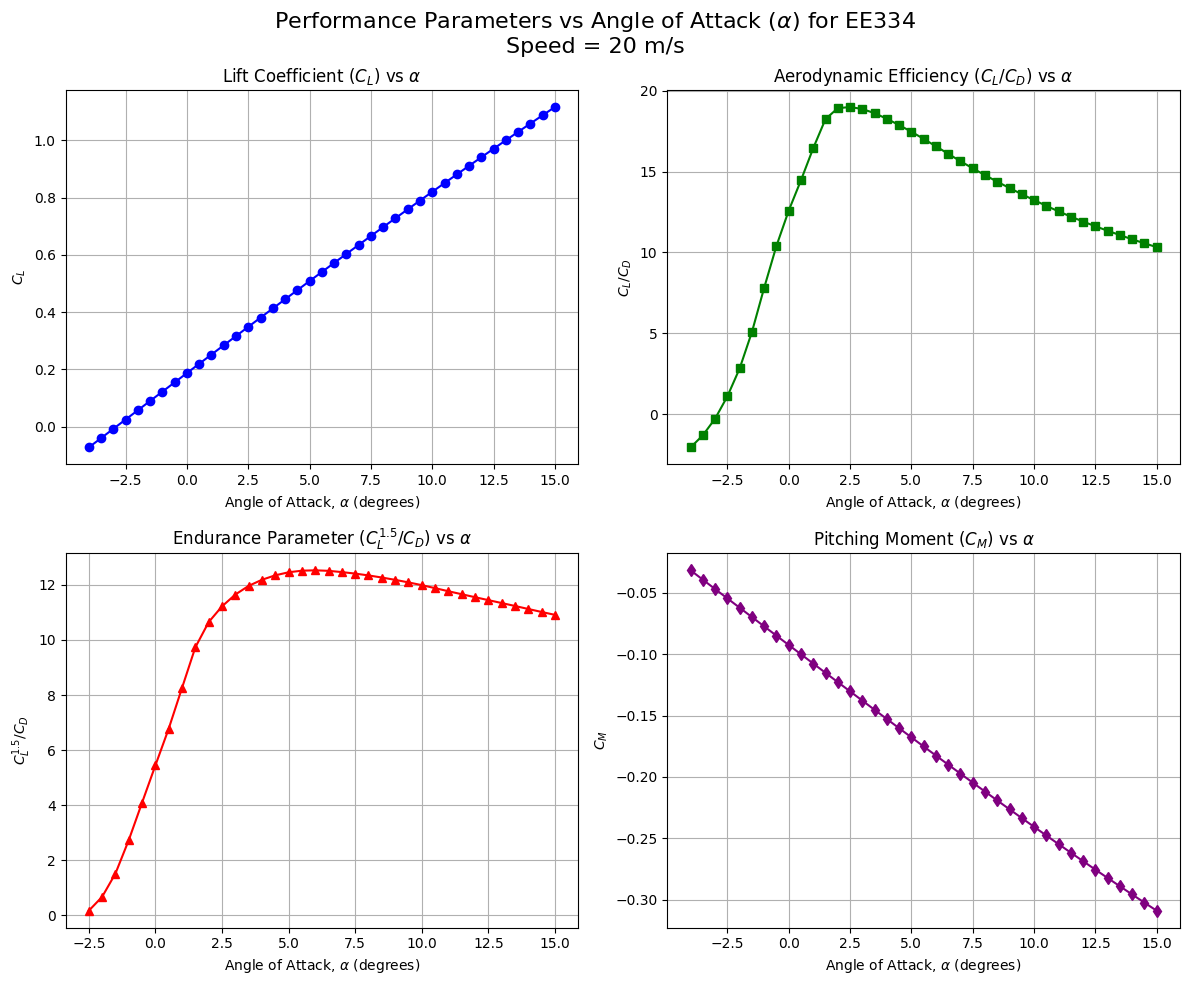

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(2023102006)

def analyze_airfoil_data(file_path, airfoil_name):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        
    header_idx = -1
    for i, line in enumerate(lines):
        if 'alpha' in line and 'CL' in line and 'CD' in line:
            header_idx = i
            break
            
    if header_idx == -1:
        raise ValueError(f"Could not find the data table in {file_path}. Check the file format.")

    df = pd.read_csv(file_path, skiprows=header_idx, delim_whitespace=True)

    df['CL/CD'] = df['CL'] / df['CD']
    df['CL^1.5/CD'] = (df['CL']**1.5) / df['CD']
    df.rename(columns={'Cm': 'CM'}, inplace=True)

    results_df = df[['alpha', 'CL', 'CL/CD', 'CL^1.5/CD', 'CM']].copy()

    print(f"\n--- Performance Parameters for {airfoil_name} ---")
    print(results_df.to_string(index=False))

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Performance Parameters vs Angle of Attack ($\\alpha$) for {airfoil_name}\nSpeed = 20 m/s', fontsize=16)

    axs[0, 0].plot(results_df['alpha'], results_df['CL'], marker='o', color='b', label='CL')
    axs[0, 0].set_title(r'Lift Coefficient ($C_L$) vs $\alpha$')
    axs[0, 0].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[0, 0].set_ylabel(r'$C_L$')
    axs[0, 0].grid(True)

    axs[0, 1].plot(results_df['alpha'], results_df['CL/CD'], marker='s', color='g', label='CL/CD')
    axs[0, 1].set_title(r'Aerodynamic Efficiency ($C_L/C_D$) vs $\alpha$')
    axs[0, 1].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[0, 1].set_ylabel(r'$C_L / C_D$')
    axs[0, 1].grid(True)

    axs[1, 0].plot(results_df['alpha'], results_df['CL^1.5/CD'], marker='^', color='r', label='CL^1.5/CD')
    axs[1, 0].set_title(r'Endurance Parameter ($C_L^{1.5}/C_D$) vs $\alpha$')
    axs[1, 0].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[1, 0].set_ylabel(r'$C_L^{1.5} / C_D$')
    axs[1, 0].grid(True)

    axs[1, 1].plot(results_df['alpha'], results_df['CM'], marker='d', color='purple', label='CM')
    axs[1, 1].set_title(r'Pitching Moment ($C_M$) vs $\alpha$')
    axs[1, 1].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[1, 1].set_ylabel(r'$C_M$')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

FILE_PATH = 'EE334_T1-20_0 m_s-VLM1.txt'  
AIRFOIL_NAME = 'EE334'    

analyze_airfoil_data(FILE_PATH, AIRFOIL_NAME)